# DDQN Test Notebook (Project-Integrated)

- Use project modules directly (`env.py`, `model.py`, `rollout.py`, `viz_matplotlib.py`, `viz_route_map.py`).
- Support testing one `.jsonl` or a folder of `.jsonl` scenarios.
- `case_mode="full_stream"`: one jsonl file as one multi-dispatch scenario.
- `case_mode="each_line"`: each line in a jsonl file is one single-dispatch testcase.


In [3]:
%matplotlib inline
import os
import json
import time
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from data_io import load_records
from env import TaskSchedulingEnv
from features import build_actions_for_tasks, q_values_batch, select_action_index
from model import QNetwork
from rollout import run_greedy_episode
from viz_matplotlib import draw_amr_schedule, draw_dispatch_queue, draw_input_queue
from viz_route_map import (
    show_route_map_replay,
    show_route_map_replay_from_jsonl,
    _robot_snapshot_at_time,
)
from viz_plotly import show_interactive_schedule_plotly


def _normalize_records(records: List[dict]) -> List[dict]:
    out: List[dict] = []
    for rec in records:
        if not isinstance(rec, dict) or "jobs" not in rec:
            raise ValueError("Each record must be a dict with key 'jobs'.")
        jobs = rec.get("jobs", [])
        if not isinstance(jobs, list):
            raise ValueError("record['jobs'] must be a list")
        out.append({
            "dispatch_time": float(rec.get("dispatch_time", 0.0)),
            "jobs": jobs,
        })
    return out


def _load_policy(model_path: str, device: torch.device, default_input_dim: int) -> nn.Module:
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}")

    ckpt = torch.load(model_path, map_location=device)
    q_kwargs = {}
    if isinstance(ckpt, dict) and "model_state" in ckpt:
        model_state = ckpt["model_state"]
        input_dim = int(ckpt.get("input_dim", default_input_dim))
        rainbow_cfg = ckpt.get("rainbow_config", {}) if isinstance(ckpt, dict) else {}
        if isinstance(rainbow_cfg, dict):
            q_kwargs = {
                "state_dim": int(rainbow_cfg.get("state_dim", input_dim - 4)),
                "action_dim": int(rainbow_cfg.get("action_dim", 4)),
                "use_rainbow": bool(rainbow_cfg.get("model_kind", "rainbow") == "rainbow"),
                "num_atoms": int(rainbow_cfg.get("num_atoms", 51)),
                "v_min": float(rainbow_cfg.get("v_min", -10000.0)),
                "v_max": float(rainbow_cfg.get("v_max", 0.0)),
                "noisy_std": float(rainbow_cfg.get("noisy_std", 0.5)),
            }
    else:
        model_state = ckpt
        input_dim = int(default_input_dim)

    model = QNetwork(input_dim, **q_kwargs).to(device)
    try:
        model.load_state_dict(model_state)
    except Exception as e:
        raise RuntimeError(
            "Checkpoint architecture mismatch with current model.py. "
            "Please use a checkpoint trained by current project code."
        ) from e
    model.eval()
    return model


def _prepare_runtime(
    model_path: str,
    allow_proactive_replenish: bool = True,
    proactive_replenish_bias_weight: float = 1.5,
    proactive_full_load_bias_weight: float = 0.8,
    proactive_waiting_replenish_bias_weight: float = 1.2,
    enable_collision_avoidance: bool = True,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env = TaskSchedulingEnv()
    env.allow_proactive_replenish = allow_proactive_replenish
    env.proactive_replenish_bias_weight = float(proactive_replenish_bias_weight)
    env.proactive_full_load_bias_weight = float(proactive_full_load_bias_weight)
    env.proactive_waiting_replenish_bias_weight = float(
        proactive_waiting_replenish_bias_weight
    )
    env.enable_collision_avoidance = enable_collision_avoidance
    state_dim = len(env.reset([]))
    action_dim = 4
    input_dim = state_dim + action_dim
    policy_net = _load_policy(model_path, device, input_dim)
    return device, env, policy_net


def run_greedy_episode_with_timing(
    env: TaskSchedulingEnv,
    policy_net: nn.Module,
    scenario: Union[dict, List[dict]],
    device: torch.device,
    log_prefix: str = "",
    print_each_step: bool = False,
) -> Tuple[float, Dict[str, float]]:
    _ = env.reset(scenario)
    s = np.array(env._get_state(), dtype=np.float32)
    done = False
    predict_step = 0
    total_predict_ms = 0.0

    while not done:
        rid = env.current_robot
        actions = build_actions_for_tasks(
            env.available_tasks,
            env.robot_inventory[rid],
            env.capacity_per_type,
            allow_proactive_replenish=env.allow_proactive_replenish,
        )
        k = len(actions)
        feats = np.zeros((k, 4), dtype=np.float32)
        for i, (task_idx, replenish) in enumerate(actions):
            task = env.available_tasks[task_idx]
            travel, wait, proc, rep = env.action_features(rid, task, replenish)
            feats[i] = (travel, wait, proc, rep)

        with torch.no_grad():
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t0 = time.perf_counter()
            q_all = q_values_batch(policy_net, s, feats, device)
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            predict_ms = (time.perf_counter() - t0) * 1000.0
            predict_step += 1
            total_predict_ms += predict_ms
            if print_each_step:
                print(f"{log_prefix}predict_step={predict_step:03d} elapsed={predict_ms:.3f} ms")
            best_idx = select_action_index(
                q_values=q_all,
                actions=actions,
                tasks=env.available_tasks,
                inventory=env.robot_inventory[rid],
                capacity_per_type=env.capacity_per_type,
                proactive_replenish_bias_weight=float(
                    getattr(env, "proactive_replenish_bias_weight", 0.0)
                ),
                action_feats=feats,
                full_load_bias_weight=float(
                    getattr(env, "proactive_full_load_bias_weight", 0.0)
                ),
                waiting_replenish_bias_weight=float(
                    getattr(env, "proactive_waiting_replenish_bias_weight", 0.0)
                ),
            )

        action = actions[best_idx]
        sp, _, done = env.step(action)
        s = np.array(sp, dtype=np.float32) if sp is not None else None

    avg_ms = (total_predict_ms / predict_step) if predict_step > 0 else 0.0
    stats = {
        "predict_steps": float(predict_step),
        "predict_total_ms": float(total_predict_ms),
        "predict_avg_ms": float(avg_ms),
    }
    return env.makespan(), stats


def _plot_case(
    env: TaskSchedulingEnv,
    scenario: Union[dict, List[dict]],
    makespan: float,
    title: str,
    save_path: Optional[str] = None,
    show_figure: bool = True,
) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))
    fig.subplots_adjust(hspace=0.45, top=0.9)
    fig.suptitle(title)

    draw_dispatch_queue(axes[0], env.trace)
    draw_amr_schedule(axes[1], env.trace, makespan, inventories=env.robot_inventory)
    draw_input_queue(axes[2], scenario)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180)
    if show_figure:
        plt.show()
    else:
        plt.close(fig)


def _export_amr_route_jsonl(
    env: TaskSchedulingEnv,
    trace: List[dict],
    out_path: str,
    time_step: float = 1.0,
    include_endpoint: bool = True,
) -> int:
    step = max(1e-6, float(time_step))
    out_file = Path(out_path)
    out_file.parent.mkdir(parents=True, exist_ok=True)

    _snap0, max_t = _robot_snapshot_at_time(env, trace, 0.0)
    max_t = max(0.0, float(max_t))
    ts = list(np.arange(0.0, max_t + 1e-9, step))
    if include_endpoint and (not ts or max_t - ts[-1] > 1e-9):
        ts.append(max_t)

    with out_file.open("w", encoding="utf-8") as f:
        for t in ts:
            snaps, _ = _robot_snapshot_at_time(env, trace, float(t))
            amrs: List[dict] = []
            for s in snaps:
                inv = s.get("inventory_net", s.get("inv", {}))
                inv_net = {
                    "A": int(inv.get("A", 0)),
                    "B": int(inv.get("B", 0)),
                    "C": int(inv.get("C", 0)),
                }
                route = s.get("route", [])
                amrs.append(
                    {
                        "rid": int(s.get("rid", -1)),
                        "name": f"AMR{int(s.get('rid', -1)) + 1}",
                        "x": float(s.get("pos", (0.0, 0.0))[0]),
                        "y": float(s.get("pos", (0.0, 0.0))[1]),
                        "status": str(s.get("status", "")),
                        "mode": str(s.get("mode", "")),
                        "jid": None if s.get("jid") is None else int(s.get("jid")),
                        "dst": s.get("dst"),
                        "inventory": dict(inv_net),
                        "inventory_net": dict(inv_net),
                        "inventory_semantics": s.get("inventory_semantics", {}),
                        "route": [[float(p[0]), float(p[1])] for p in route],
                        "proc_elapsed": float(s.get("proc_elapsed", 0.0)),
                        "proc_total": float(s.get("proc_total", 0.0)),
                        "proc_remaining": float(s.get("proc_remaining", 0.0)),
                    }
                )

            rec = {
                "t": float(round(float(t), 6)),
                "amrs": amrs,
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    return len(ts)


def _summary_line(results: List[Dict[str, object]], title: str = "SUMMARY") -> str:
    if not results:
        return f"{title}|cases=0"

    mk = np.asarray([float(r["makespan"]) for r in results], dtype=np.float64)
    solve_ms = np.asarray([float(r.get("solve_time_ms", 0.0)) for r in results], dtype=np.float64)

    return (
        f"{title}|cases={len(results)}|"
        f"mk_avg={mk.mean():.3f}|mk_std={mk.std(ddof=0):.3f}|"
        f"mk_min={mk.min():.3f}|mk_max={mk.max():.3f}|"
        f"solve_ms_avg={solve_ms.mean():.3f}|solve_ms_std={solve_ms.std(ddof=0):.3f}|"
        f"solve_ms_min={solve_ms.min():.3f}|solve_ms_max={solve_ms.max():.3f}|"
        f"solve_s_total={(solve_ms.sum() / 1000.0):.6f}"
    )


def _print_summary(results: List[Dict[str, object]], title: str = "SUMMARY") -> str:
    line = _summary_line(results, title=title)
    print(line)
    return line


def _case_stat_lines(results: List[Dict[str, object]]) -> List[str]:
    lines: List[str] = []
    ordered = sorted(results, key=lambda r: (str(r.get("file", "")), int(r.get("case_id", -1))))
    for r in ordered:
        fname = str(r.get("file", ""))
        mode = str(r.get("mode", ""))
        case_id = int(r.get("case_id", -1))
        mk = float(r.get("makespan", 0.0))
        solve_ms = float(r.get("solve_time_ms", 0.0))
        solve_s = float(r.get("solve_time_s", solve_ms / 1000.0))

        if mode == "full_stream":
            prefix = "STREAM"
        else:
            prefix = f"CASE {case_id:03d}"

        lines.append(
            f"[{fname}] {prefix} makespan={mk:.3f} "
            f"solve_ms={solve_ms:.3f} solve_s={solve_s:.6f}"
        )

    return lines


def _per_file_summary_lines(results: List[Dict[str, object]]) -> List[str]:
    grouped: Dict[str, List[Dict[str, object]]] = defaultdict(list)
    for r in results:
        grouped[str(r.get("file", ""))].append(r)

    lines: List[str] = []
    for fname in sorted(grouped.keys()):
        rs = grouped[fname]
        mk = np.asarray([float(x.get("makespan", 0.0)) for x in rs], dtype=np.float64)
        solve_ms = np.asarray([float(x.get("solve_time_ms", 0.0)) for x in rs], dtype=np.float64)
        lines.append(
            f"PER_FILE|file={fname}|cases={len(rs)}|"
            f"mk_avg={mk.mean():.3f}|mk_min={mk.min():.3f}|mk_max={mk.max():.3f}|"
            f"solve_ms_avg={solve_ms.mean():.3f}|solve_ms_total={solve_ms.sum():.3f}"
        )
    return lines


def _write_stats_txt(path: str, lines: List[str], append: bool = False) -> None:
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    mode = "a" if append else "w"
    with out.open(mode, encoding="utf-8") as f:
        for line in lines:
            f.write(str(line) + "\n")




def replay_saved_route_jsonl(
    route_jsonl_path: str,
    initial_t: float = 0.0,
    play_interval_ms: int = 120,
) -> None:
    """Replay AMR route directly from an exported route jsonl file."""
    env = TaskSchedulingEnv()
    show_route_map_replay_from_jsonl(
        env,
        route_jsonl_path,
        initial_t=initial_t,
        play_interval_ms=play_interval_ms,
    )

def run_single_jsonl(
    jsonl_path: str,
    model_path: str = "ddqn_policy_rainbow.pt",
    case_mode: str = "full_stream",  # "full_stream" | "each_line"
    max_cases: Optional[int] = None,
    plot: bool = False,
    save_plots: bool = False,
    plot_dir: str = "test_plots",
    show_route_map: bool = False,
    show_route_map_use_saved_jsonl: bool = True,
    show_plotly: bool = False,
    plotly_html_dir: str = "test_plots_html",
    plotly_window: float = 80.0,
    plotly_step: float = 5.0,
    save_route_jsonl: bool = False,
    route_jsonl_dir: str = "test_route_logs",
    route_time_step: float = 1.0,
    allow_proactive_replenish: bool = True,
    proactive_replenish_bias_weight: float = 1.5,
    proactive_full_load_bias_weight: float = 0.8,
    proactive_waiting_replenish_bias_weight: float = 1.2,
    enable_collision_avoidance: bool = True,
    print_predict_time: bool = False,
    _runtime=None,
) -> List[Dict[str, object]]:
    if case_mode not in {"full_stream", "each_line"}:
        raise ValueError("case_mode must be 'full_stream' or 'each_line'")

    raw_records = load_records(jsonl_path)
    records = _normalize_records(raw_records)
    if not records:
        raise RuntimeError(f"No records found in {jsonl_path}")

    if _runtime is None:
        device, env, policy_net = _prepare_runtime(
            model_path,
            allow_proactive_replenish,
            proactive_replenish_bias_weight,
            proactive_full_load_bias_weight,
            proactive_waiting_replenish_bias_weight,
            enable_collision_avoidance,
        )
        print("device =", device)
    else:
        device, env, policy_net = _runtime

    file_name = Path(jsonl_path).name
    if case_mode == "full_stream":
        scenarios: List[Tuple[int, Union[dict, List[dict]]]] = [(0, records)]
    else:
        total = len(records) if max_cases is None else min(len(records), max_cases)
        scenarios = [(i, records[i]) for i in range(total)]

    results: List[Dict[str, object]] = []
    case_logs: List[str] = []
    file_solve_total_ms = 0.0
    for idx, scenario in scenarios:
        predict_stats: Optional[Dict[str, float]] = None
        if print_predict_time:
            log_prefix = f"[{file_name}|case={idx:03d}] "
            mk, predict_stats = run_greedy_episode_with_timing(
                env,
                policy_net,
                scenario,
                device,
                log_prefix=log_prefix,
                print_each_step=False,
            )
            mk = float(mk)
            solve_time_ms = float(predict_stats["predict_total_ms"])
        else:
            t0 = time.perf_counter()
            mk = float(run_greedy_episode(env, policy_net, scenario, device))
            solve_time_ms = (time.perf_counter() - t0) * 1000.0
        solve_time_s = solve_time_ms / 1000.0

        row: Dict[str, object] = {
            "file": file_name,
            "case_id": int(idx),
            "mode": case_mode,
            "makespan": mk,
            "solve_time_ms": float(solve_time_ms),
            "solve_time_s": float(solve_time_s),
        }
        if predict_stats is not None:
            row["predict_steps"] = int(predict_stats["predict_steps"])
            row["predict_total_ms"] = float(predict_stats["predict_total_ms"])
            row["predict_avg_ms"] = float(predict_stats["predict_avg_ms"])
        results.append(row)
        file_solve_total_ms += float(solve_time_ms)

        if case_mode == "full_stream":
            case_logs.append(
                f"[{file_name}] STREAM makespan={mk:.3f} "
                f"solve_ms={solve_time_ms:.3f} solve_s={solve_time_s:.6f}"
            )
        else:
            case_logs.append(
                f"[{file_name}] CASE {idx:03d} makespan={mk:.3f} "
                f"solve_ms={solve_time_ms:.3f} solve_s={solve_time_s:.6f}"
            )

        case_title = f"{file_name} | mode={case_mode} | case={idx:03d} | mk={mk:.2f}s"

        if save_route_jsonl:
            route_dir = Path(route_jsonl_dir)
            route_dir.mkdir(parents=True, exist_ok=True)
            route_name = f"{Path(file_name).stem}_case_{idx:03d}_amr_path.jsonl"
            route_path = str(route_dir / route_name)
            line_count = _export_amr_route_jsonl(
                env,
                env.trace,
                route_path,
                time_step=route_time_step,
                include_endpoint=True,
            )
            row["route_jsonl_path"] = route_path
            row["route_jsonl_lines"] = int(line_count)

        if plot or save_plots:
            out_path = None
            if save_plots:
                out_name = f"{Path(file_name).stem}_case_{idx:03d}.png"
                out_path = os.path.join(plot_dir, out_name)
            _plot_case(env, scenario, mk, title=case_title, save_path=out_path, show_figure=plot)

        if show_plotly:
            html_dir = Path(plotly_html_dir)
            html_dir.mkdir(parents=True, exist_ok=True)
            html_name = f"{Path(file_name).stem}_case_{idx:03d}.html"
            html_path = str(html_dir / html_name)
            show_interactive_schedule_plotly(
                trace=env.trace,
                input_source=scenario,
                makespan=mk,
                inventories=env.robot_inventory,
                window=plotly_window,
                step=plotly_step,
                html_path=html_path,
                title_info=case_title,
            )

        if show_route_map:
            route_path_for_replay = row.get("route_jsonl_path", None)
            if show_route_map_use_saved_jsonl and route_path_for_replay:
                show_route_map_replay_from_jsonl(
                    env,
                    str(route_path_for_replay),
                    initial_t=0.0,
                    play_interval_ms=120,
                )
            else:
                show_route_map_replay(
                    env, env.trace, initial_t=0.0, play_step=0.5, play_interval_ms=120
                )

    for msg in case_logs:
        print(msg)

    if scenarios:
        file_solve_avg_ms = file_solve_total_ms / float(len(scenarios))
        print(
            f"[{file_name}] SOLVE_TIME "
            f"avg={file_solve_avg_ms:.3f}ms total={file_solve_total_ms:.3f}ms "
            f"cases={len(scenarios)}"
        )

    return results


def run_test_case_folder(
    folder_path: str,
    model_path: str = "ddqn_policy_rainbow.pt",
    case_mode: str = "full_stream",
    max_files: Optional[int] = None,
    max_cases_per_file: Optional[int] = None,
    plot: bool = False,
    save_plots: bool = False,
    plot_dir: str = "test_plots",
    show_route_map: bool = False,
    show_route_map_use_saved_jsonl: bool = True,
    show_plotly: bool = False,
    plotly_html_dir: str = "test_plots_html",
    plotly_window: float = 80.0,
    plotly_step: float = 5.0,
    save_route_jsonl: bool = False,
    route_jsonl_dir: str = "test_route_logs",
    route_time_step: float = 1.0,
    allow_proactive_replenish: bool = True,
    proactive_replenish_bias_weight: float = 1.5,
    proactive_full_load_bias_weight: float = 0.8,
    proactive_waiting_replenish_bias_weight: float = 1.2,
    enable_collision_avoidance: bool = True,
    print_predict_time: bool = False,
) -> List[Dict[str, object]]:
    folder = Path(folder_path)
    if not folder.exists() or not folder.is_dir():
        raise NotADirectoryError(f"Not a directory: {folder_path}")

    files = sorted(folder.glob("*.jsonl"))
    if not files:
        raise RuntimeError(f"No jsonl files found in {folder_path}")
    if max_files is not None:
        files = files[: max(0, int(max_files))]

    device, env, policy_net = _prepare_runtime(
        model_path,
        allow_proactive_replenish,
        proactive_replenish_bias_weight,
        proactive_full_load_bias_weight,
        proactive_waiting_replenish_bias_weight,
        enable_collision_avoidance,
    )
    print("device =", device)

    all_results: List[Dict[str, object]] = []
    for fp in files:
        file_results = run_single_jsonl(
            jsonl_path=str(fp),
            model_path=model_path,
            case_mode=case_mode,
            max_cases=max_cases_per_file,
            plot=plot,
            save_plots=save_plots,
            plot_dir=plot_dir,
            show_route_map=show_route_map,
            show_route_map_use_saved_jsonl=show_route_map_use_saved_jsonl,
            show_plotly=show_plotly,
            plotly_html_dir=plotly_html_dir,
            plotly_window=plotly_window,
            plotly_step=plotly_step,
            save_route_jsonl=save_route_jsonl,
            route_jsonl_dir=route_jsonl_dir,
            route_time_step=route_time_step,
            allow_proactive_replenish=allow_proactive_replenish,
            proactive_replenish_bias_weight=proactive_replenish_bias_weight,
            proactive_full_load_bias_weight=proactive_full_load_bias_weight,
            proactive_waiting_replenish_bias_weight=proactive_waiting_replenish_bias_weight,
            enable_collision_avoidance=enable_collision_avoidance,
            print_predict_time=print_predict_time,
            _runtime=(device, env, policy_net),
        )
        all_results.extend(file_results)

    # per-file summary
    grouped: Dict[str, List[Dict[str, object]]] = defaultdict(list)
    for r in all_results:
        grouped[str(r["file"])].append(r)

    print("\n====== PER-FILE SUMMARY ======")
    for fname in sorted(grouped.keys()):
        rs = grouped[fname]
        mk = np.asarray([float(x["makespan"]) for x in rs], dtype=np.float64)
        solve_ms = np.asarray([float(x.get("solve_time_ms", 0.0)) for x in rs], dtype=np.float64)
        print(
            f"{fname}: cases={len(rs)} "
            f"mk_avg={mk.mean():.3f} mk_min={mk.min():.3f} mk_max={mk.max():.3f} "
            f"solve_ms_avg={solve_ms.mean():.3f} solve_ms_total={solve_ms.sum():.3f}"
        )
    print("==============================")

    return all_results


def run_tests(
    target_path: str,
    model_path: str = "ddqn_policy_rainbow.pt",
    case_mode: str = "full_stream",
    max_files: Optional[int] = None,
    max_cases_per_file: Optional[int] = None,
    plot: bool = False,
    save_plots: bool = False,
    plot_dir: str = "test_plots",
    show_route_map: bool = False,
    show_route_map_use_saved_jsonl: bool = True,
    show_plotly: bool = False,
    plotly_html_dir: str = "test_plots_html",
    plotly_window: float = 80.0,
    plotly_step: float = 5.0,
    save_route_jsonl: bool = False,
    route_jsonl_dir: str = "test_route_logs",
    route_time_step: float = 1.0,
    save_stats_txt: bool = False,
    stats_txt_path: str = "test_output/test_stats.txt",
    stats_txt_append: bool = False,
    allow_proactive_replenish: bool = True,
    proactive_replenish_bias_weight: float = 1.5,
    proactive_full_load_bias_weight: float = 0.8,
    proactive_waiting_replenish_bias_weight: float = 1.2,
    enable_collision_avoidance: bool = True,
    print_predict_time: bool = False,
) -> List[Dict[str, object]]:
    p = Path(target_path)
    if p.is_dir():
        results = run_test_case_folder(
            folder_path=str(p),
            model_path=model_path,
            case_mode=case_mode,
            max_files=max_files,
            max_cases_per_file=max_cases_per_file,
            plot=plot,
            save_plots=save_plots,
            plot_dir=plot_dir,
            show_route_map=show_route_map,
            show_route_map_use_saved_jsonl=show_route_map_use_saved_jsonl,
            show_plotly=show_plotly,
            plotly_html_dir=plotly_html_dir,
            plotly_window=plotly_window,
            plotly_step=plotly_step,
            save_route_jsonl=save_route_jsonl,
            route_jsonl_dir=route_jsonl_dir,
            route_time_step=route_time_step,
            allow_proactive_replenish=allow_proactive_replenish,
            proactive_replenish_bias_weight=proactive_replenish_bias_weight,
            proactive_full_load_bias_weight=proactive_full_load_bias_weight,
            proactive_waiting_replenish_bias_weight=proactive_waiting_replenish_bias_weight,
            enable_collision_avoidance=enable_collision_avoidance,
            print_predict_time=print_predict_time,
        )
        summary_line = _print_summary(results, title=f"FOLDER SUMMARY ({p.name})")
        if save_stats_txt:
            txt_lines: List[str] = []
            txt_lines.append(f"RUN|target={target_path}|mode={case_mode}|scope=folder")
            txt_lines.extend(_case_stat_lines(results))
            txt_lines.extend(_per_file_summary_lines(results))
            txt_lines.append(summary_line)
            _write_stats_txt(stats_txt_path, txt_lines, append=stats_txt_append)
            print(f"stats_txt={stats_txt_path} lines={len(txt_lines)}")
        return results

    if p.is_file():
        results = run_single_jsonl(
            jsonl_path=str(p),
            model_path=model_path,
            case_mode=case_mode,
            max_cases=max_cases_per_file,
            plot=plot,
            save_plots=save_plots,
            plot_dir=plot_dir,
            show_route_map=show_route_map,
            show_route_map_use_saved_jsonl=show_route_map_use_saved_jsonl,
            show_plotly=show_plotly,
            plotly_html_dir=plotly_html_dir,
            plotly_window=plotly_window,
            plotly_step=plotly_step,
            save_route_jsonl=save_route_jsonl,
            route_jsonl_dir=route_jsonl_dir,
            route_time_step=route_time_step,
            allow_proactive_replenish=allow_proactive_replenish,
            proactive_replenish_bias_weight=proactive_replenish_bias_weight,
            proactive_full_load_bias_weight=proactive_full_load_bias_weight,
            proactive_waiting_replenish_bias_weight=proactive_waiting_replenish_bias_weight,
            enable_collision_avoidance=enable_collision_avoidance,
            print_predict_time=print_predict_time,
        )
        summary_line = _print_summary(results, title=f"FILE SUMMARY ({p.name})")
        if save_stats_txt:
            txt_lines: List[str] = []
            txt_lines.append(f"RUN|target={target_path}|mode={case_mode}|scope=file")
            txt_lines.extend(_case_stat_lines(results))
            txt_lines.extend(_per_file_summary_lines(results))
            txt_lines.append(summary_line)
            _write_stats_txt(stats_txt_path, txt_lines, append=stats_txt_append)
            print(f"stats_txt={stats_txt_path} lines={len(txt_lines)}")
        return results

    raise FileNotFoundError(f"Path not found: {target_path}")


device = cuda


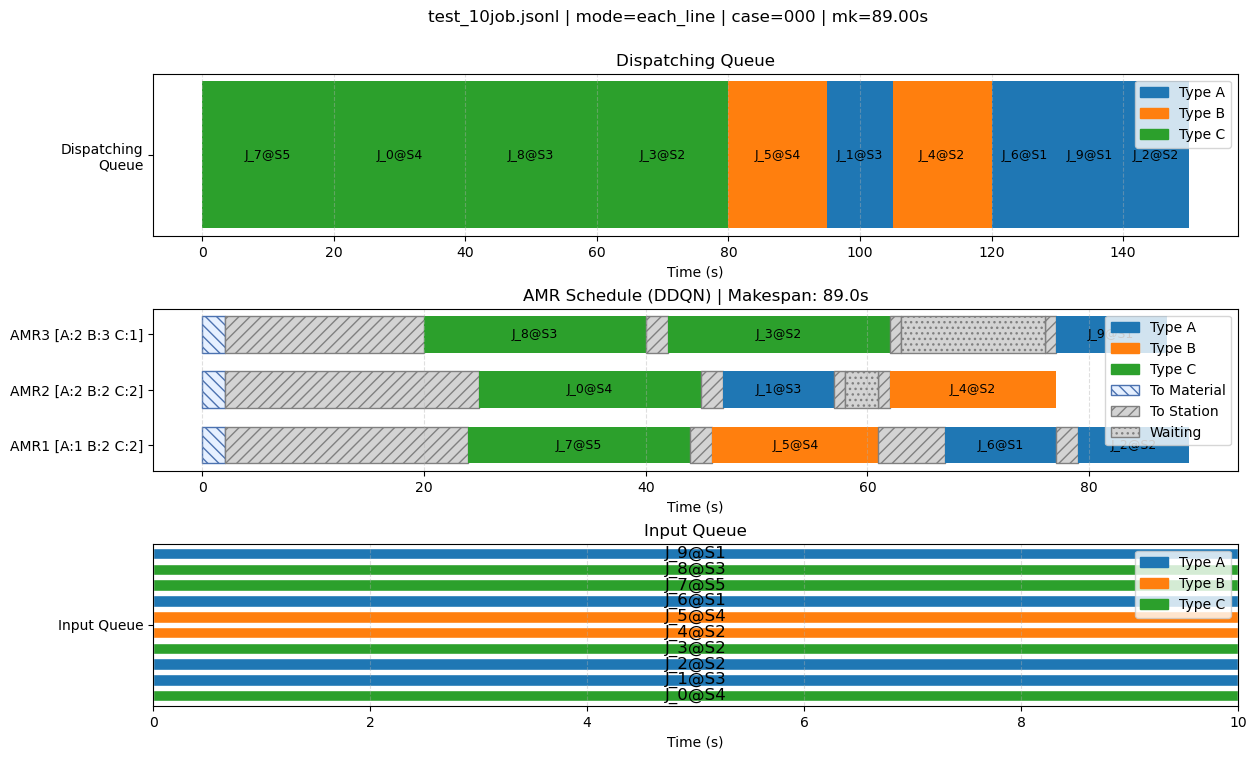

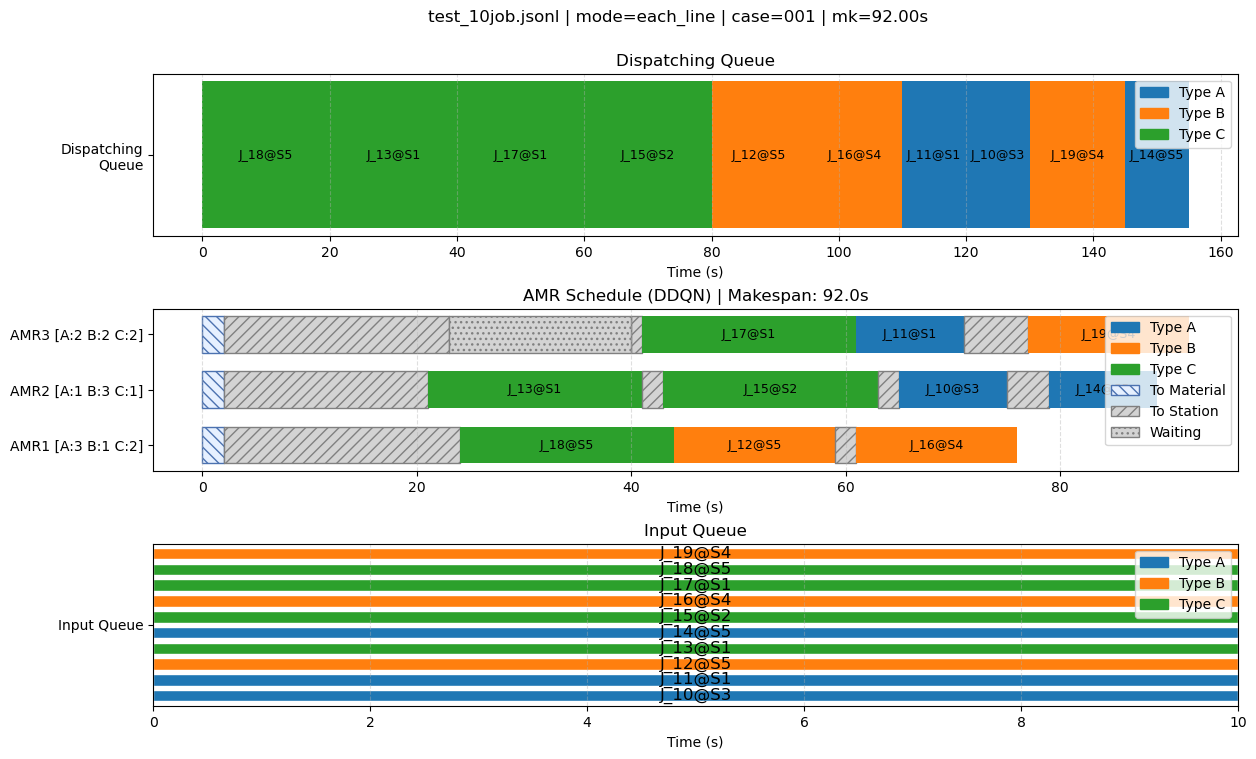

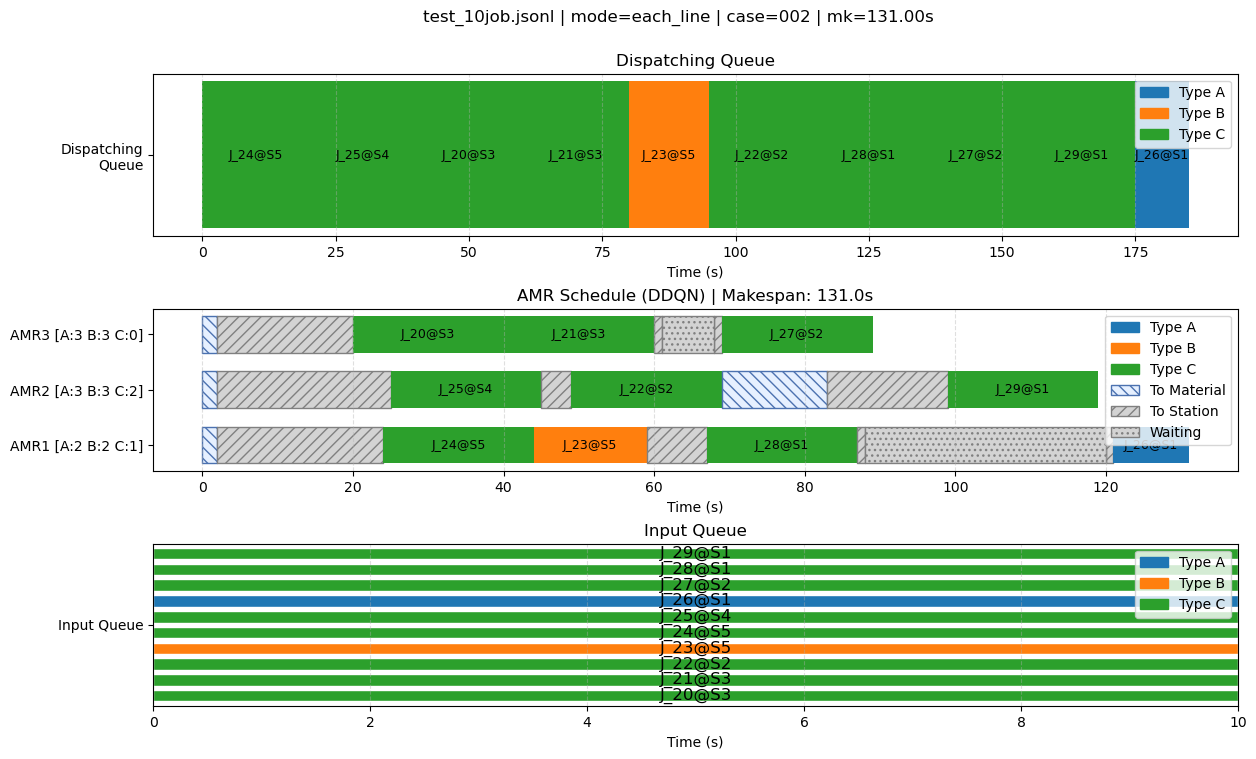

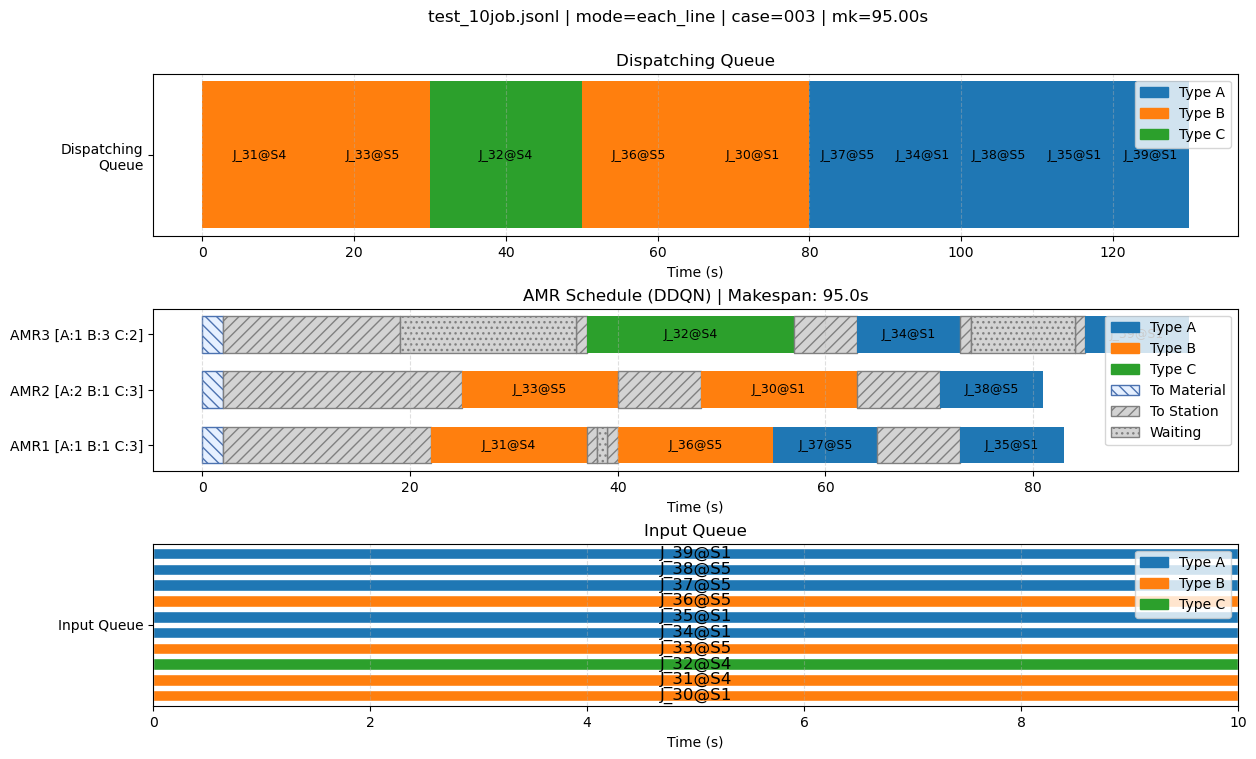

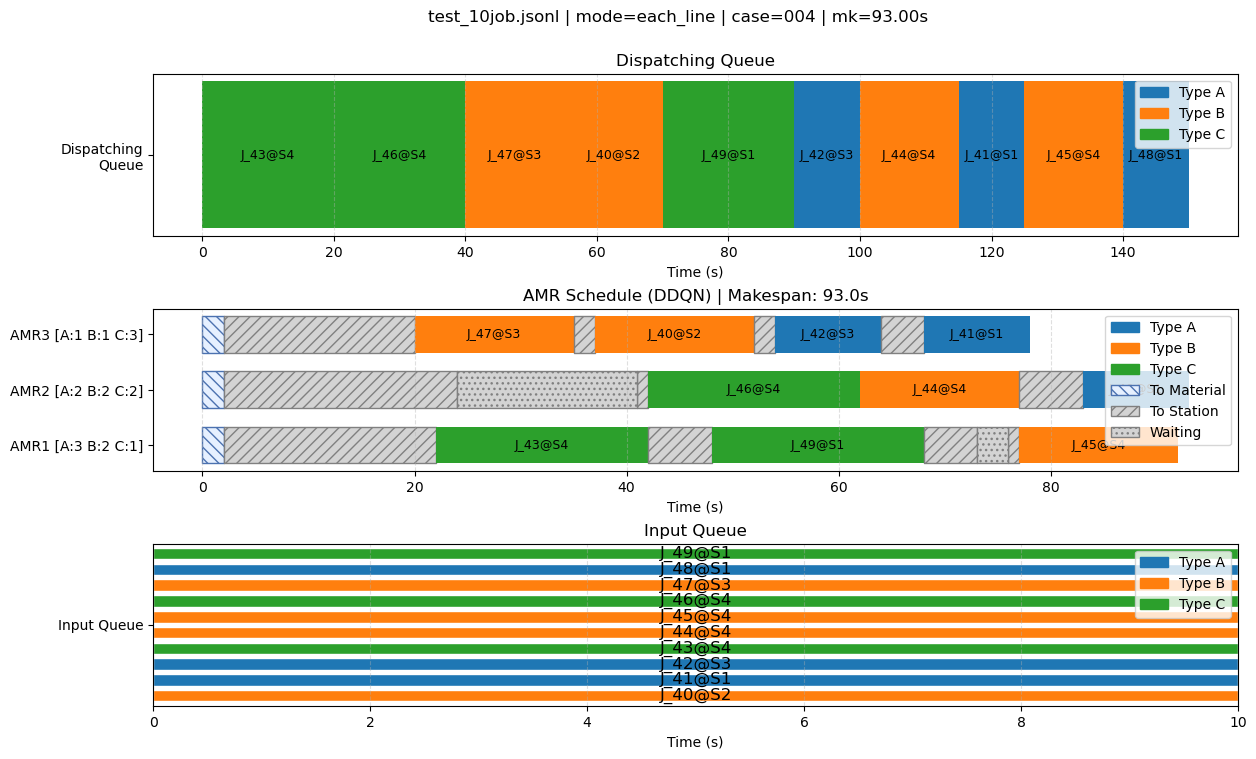

[test_10job.jsonl] CASE 000 makespan=89.000 solve_ms=32.106 solve_s=0.032106
[test_10job.jsonl] CASE 001 makespan=92.000 solve_ms=16.562 solve_s=0.016562
[test_10job.jsonl] CASE 002 makespan=131.000 solve_ms=34.288 solve_s=0.034288
[test_10job.jsonl] CASE 003 makespan=95.000 solve_ms=28.635 solve_s=0.028635
[test_10job.jsonl] CASE 004 makespan=93.000 solve_ms=25.506 solve_s=0.025506
[test_10job.jsonl] SOLVE_TIME avg=27.420ms total=137.098ms cases=5


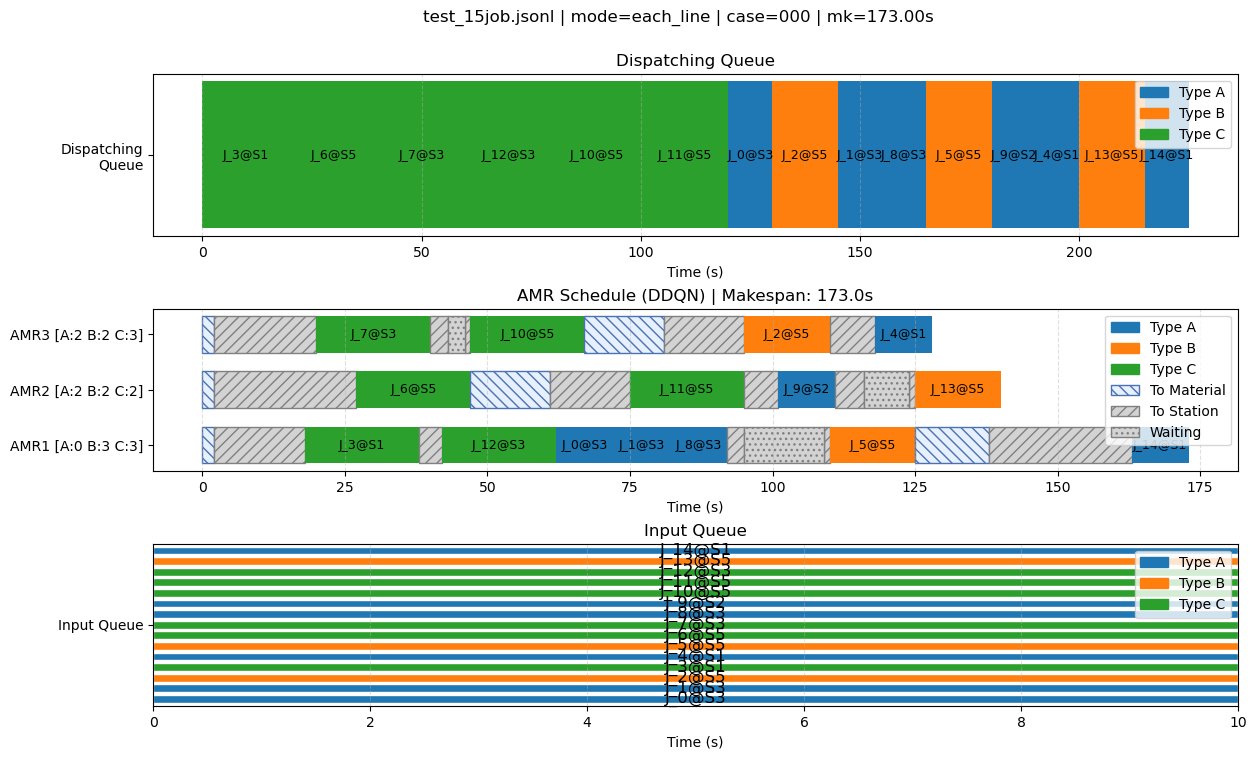

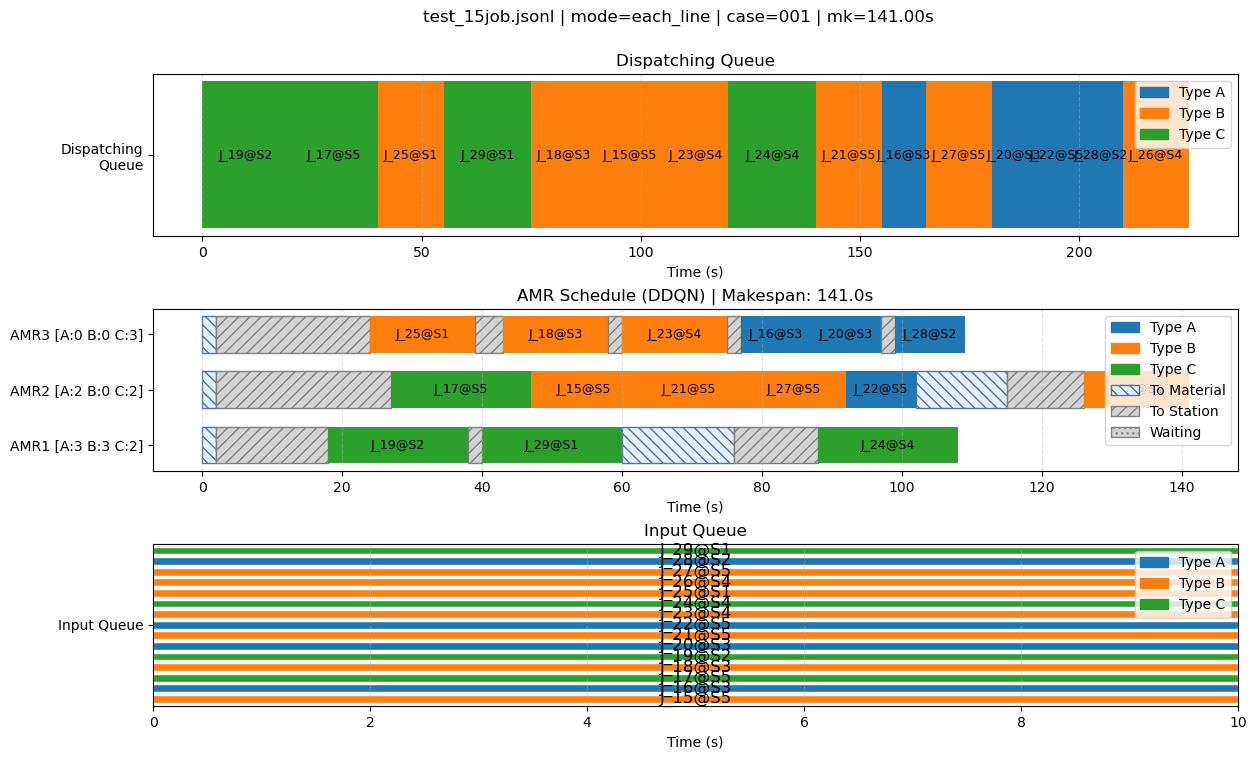

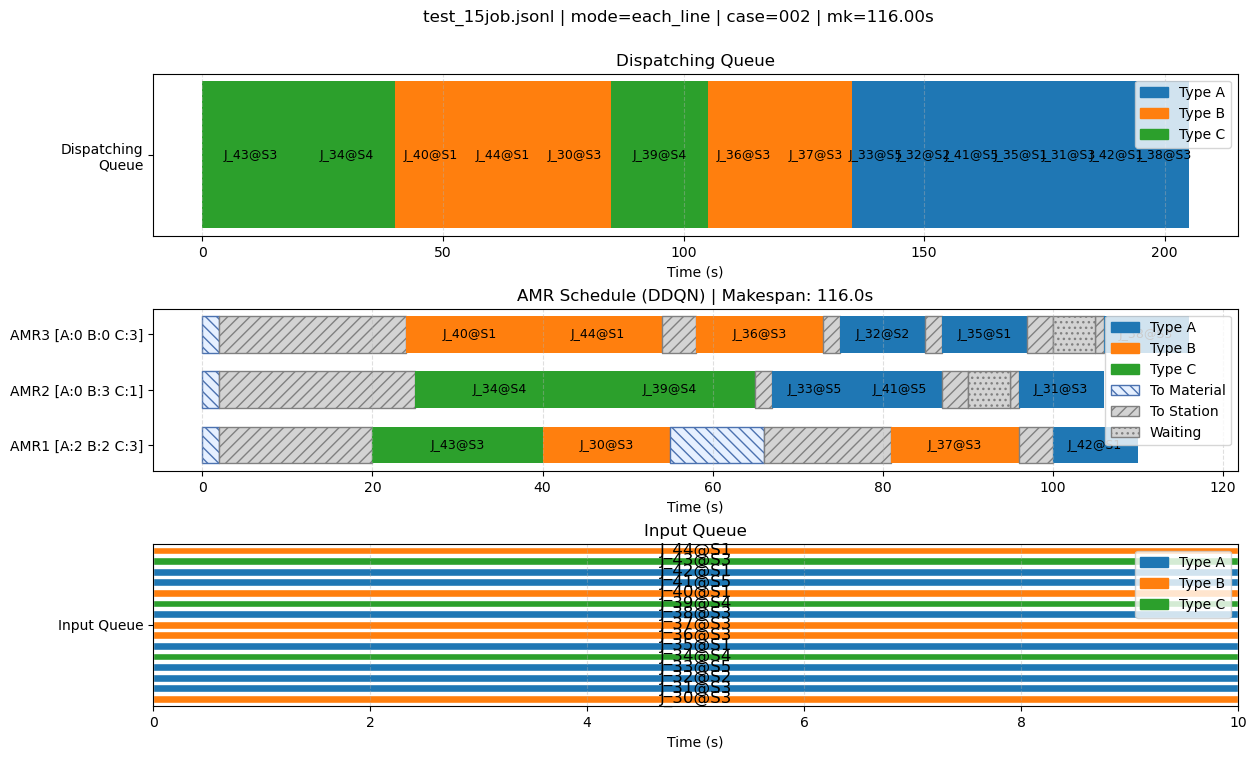

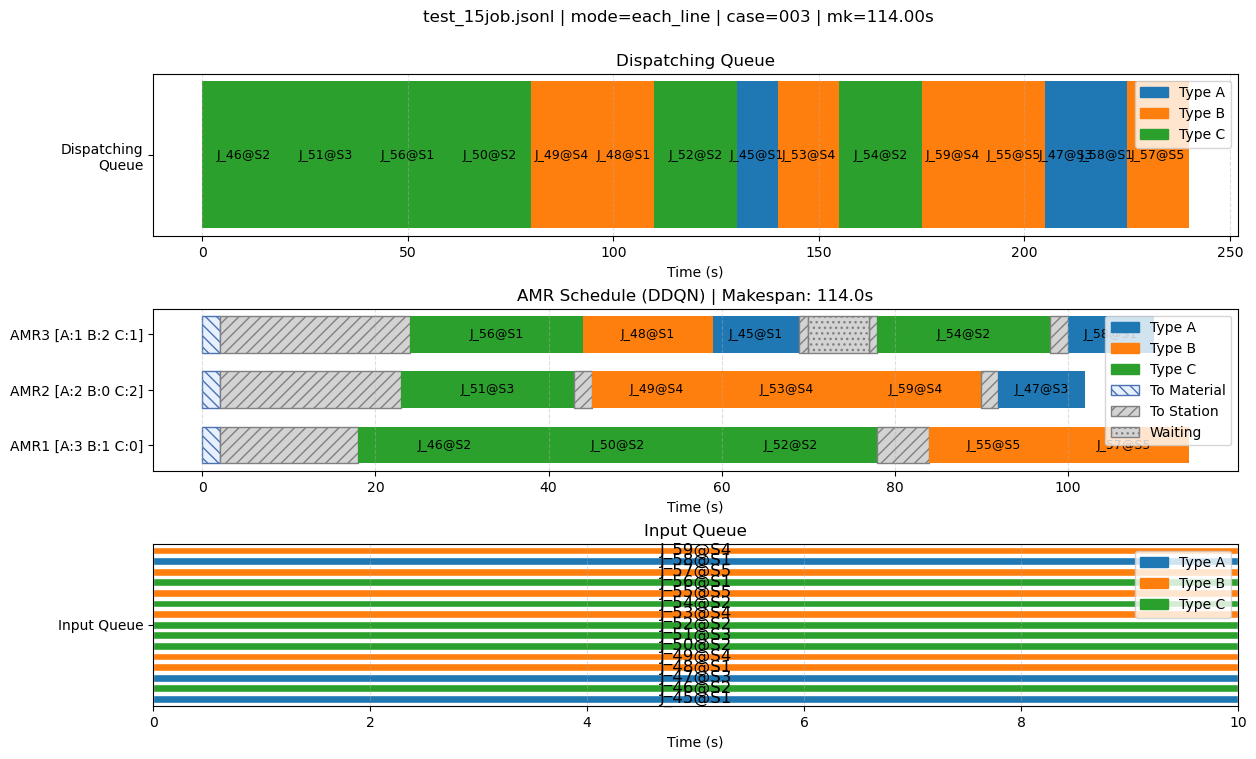

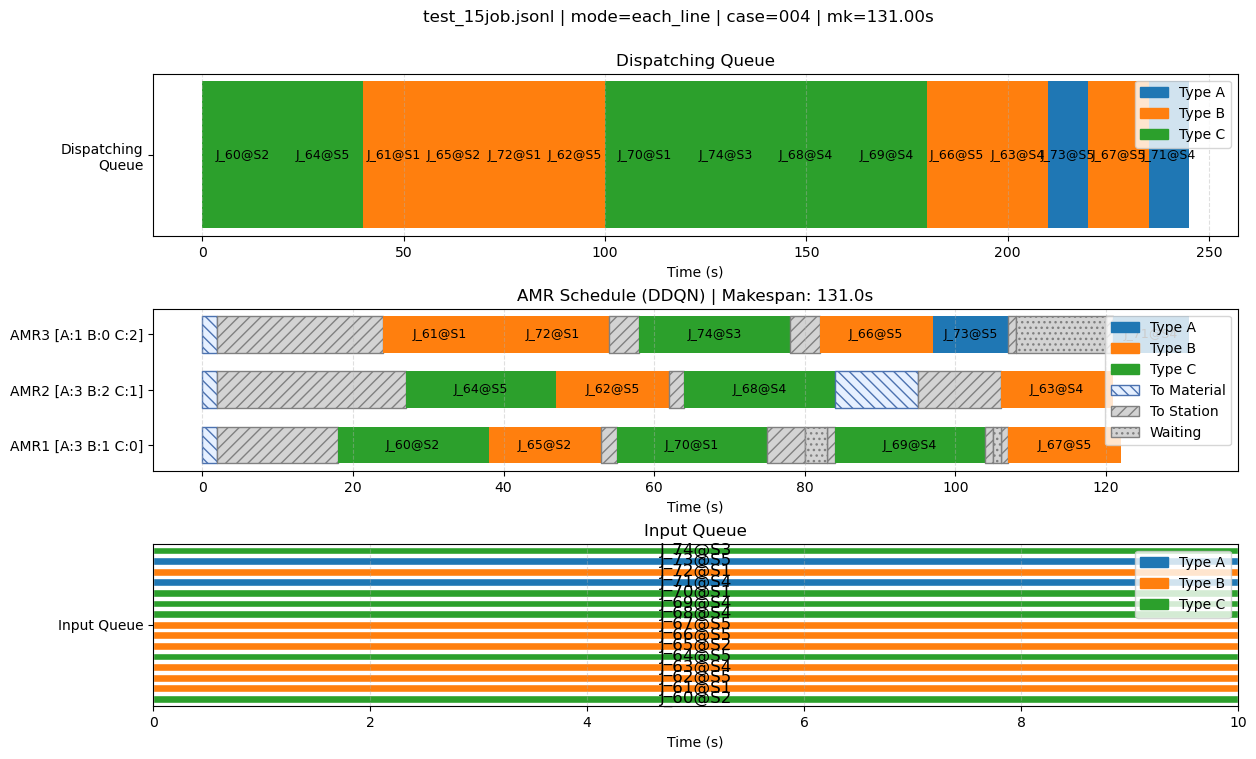

[test_15job.jsonl] CASE 000 makespan=173.000 solve_ms=43.082 solve_s=0.043082
[test_15job.jsonl] CASE 001 makespan=141.000 solve_ms=43.059 solve_s=0.043059
[test_15job.jsonl] CASE 002 makespan=116.000 solve_ms=42.037 solve_s=0.042037
[test_15job.jsonl] CASE 003 makespan=114.000 solve_ms=43.750 solve_s=0.043750
[test_15job.jsonl] CASE 004 makespan=131.000 solve_ms=41.788 solve_s=0.041788
[test_15job.jsonl] SOLVE_TIME avg=42.743ms total=213.715ms cases=5


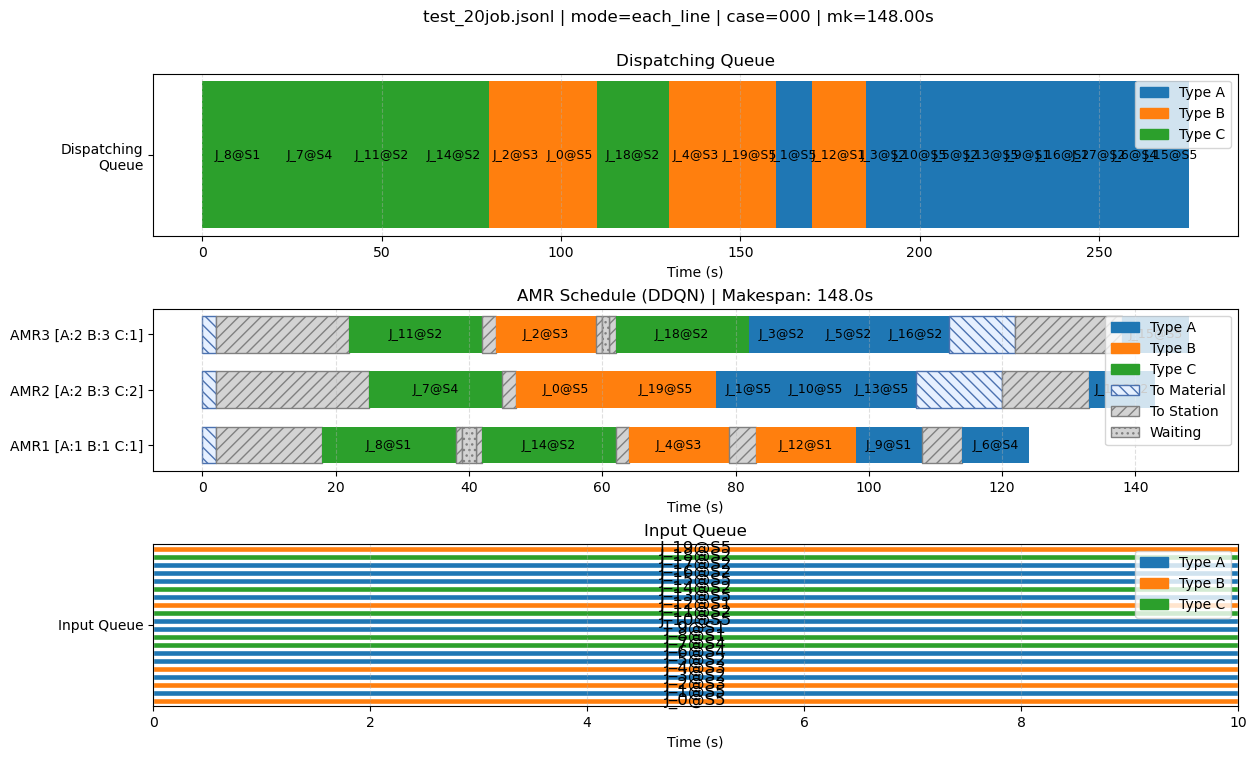

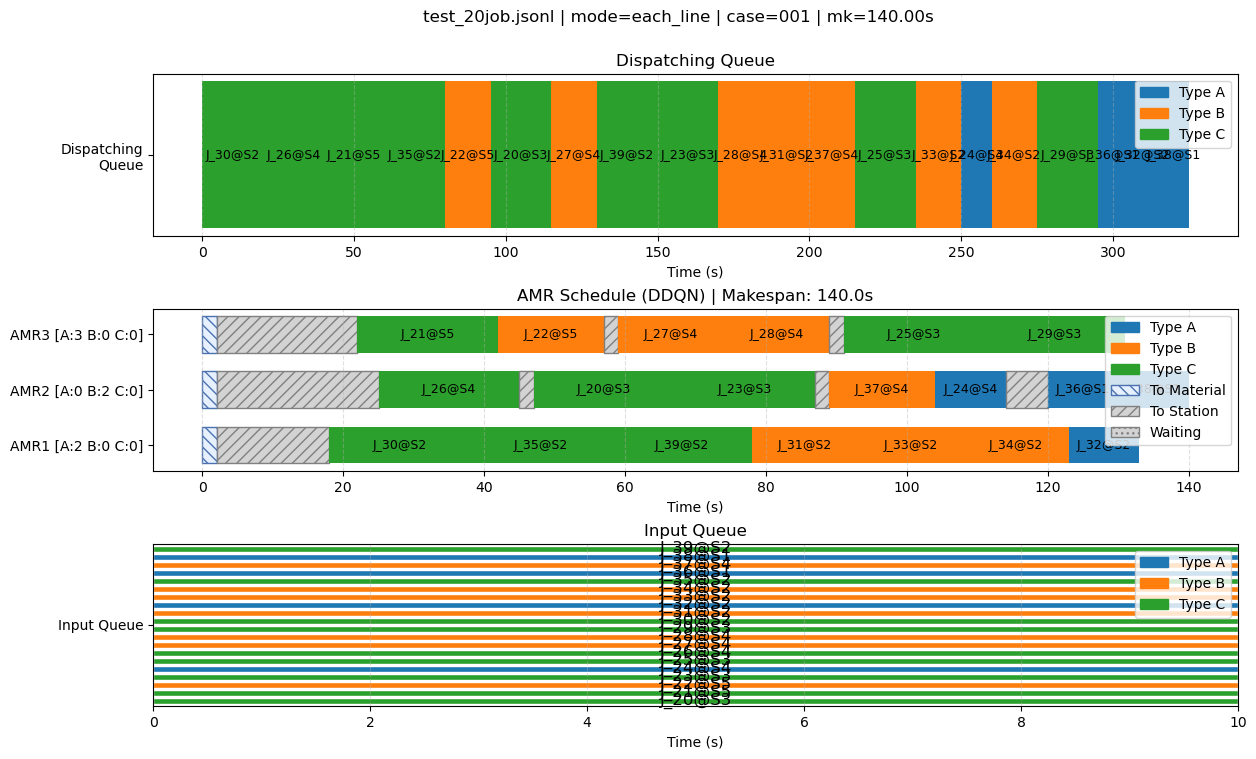

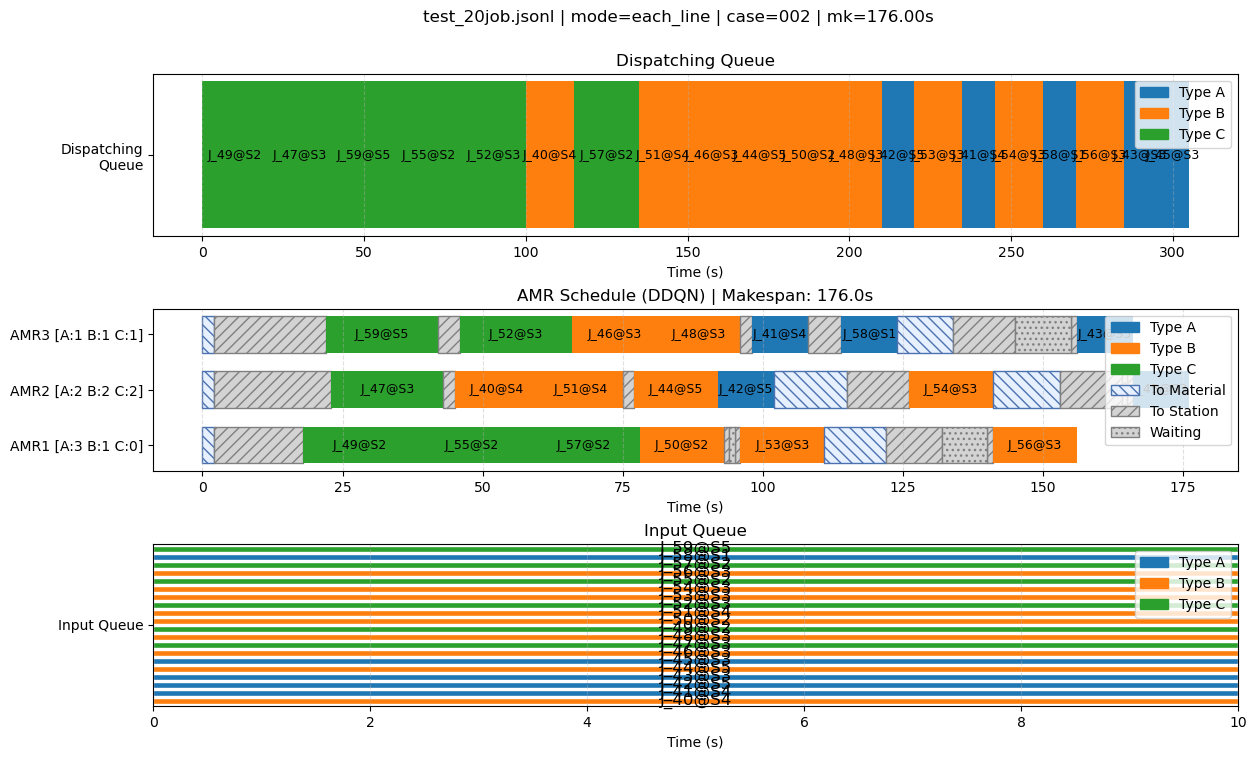

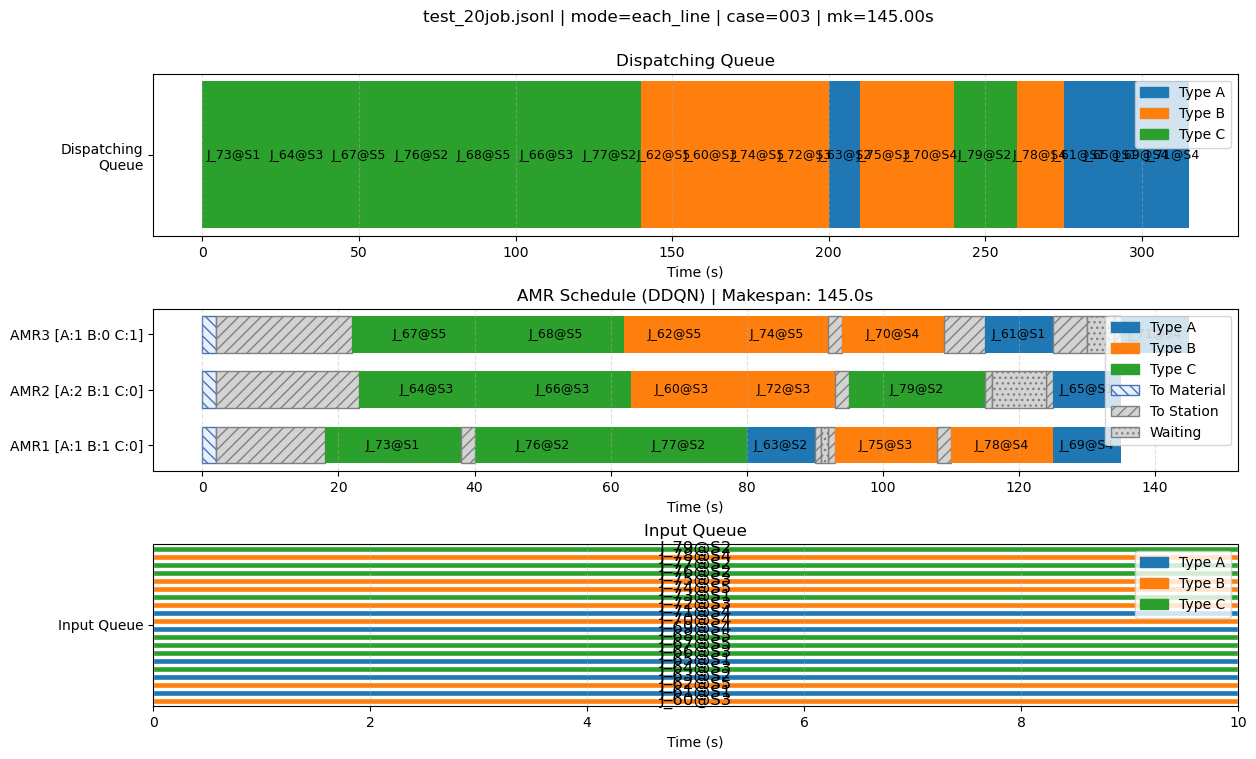

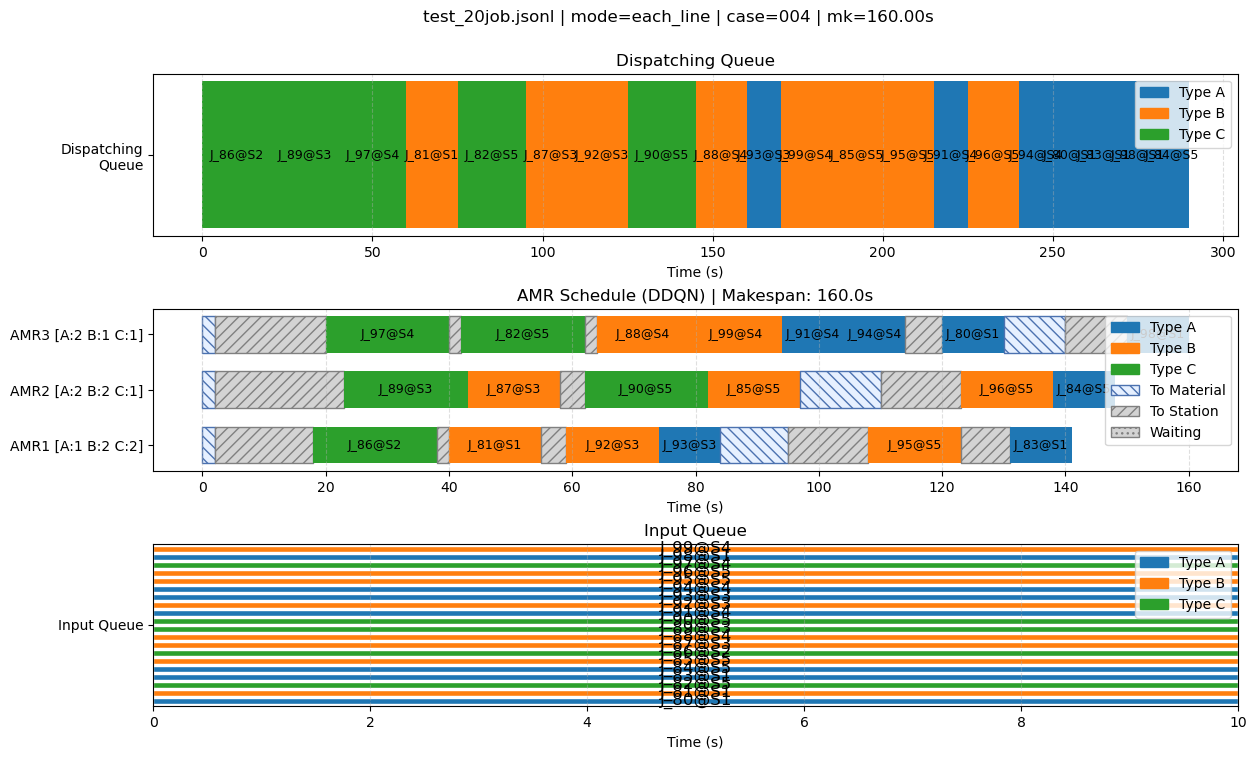

[test_20job.jsonl] CASE 000 makespan=148.000 solve_ms=48.057 solve_s=0.048057
[test_20job.jsonl] CASE 001 makespan=140.000 solve_ms=49.367 solve_s=0.049367
[test_20job.jsonl] CASE 002 makespan=176.000 solve_ms=56.734 solve_s=0.056734
[test_20job.jsonl] CASE 003 makespan=145.000 solve_ms=55.114 solve_s=0.055114
[test_20job.jsonl] CASE 004 makespan=160.000 solve_ms=56.018 solve_s=0.056018
[test_20job.jsonl] SOLVE_TIME avg=53.058ms total=265.290ms cases=5


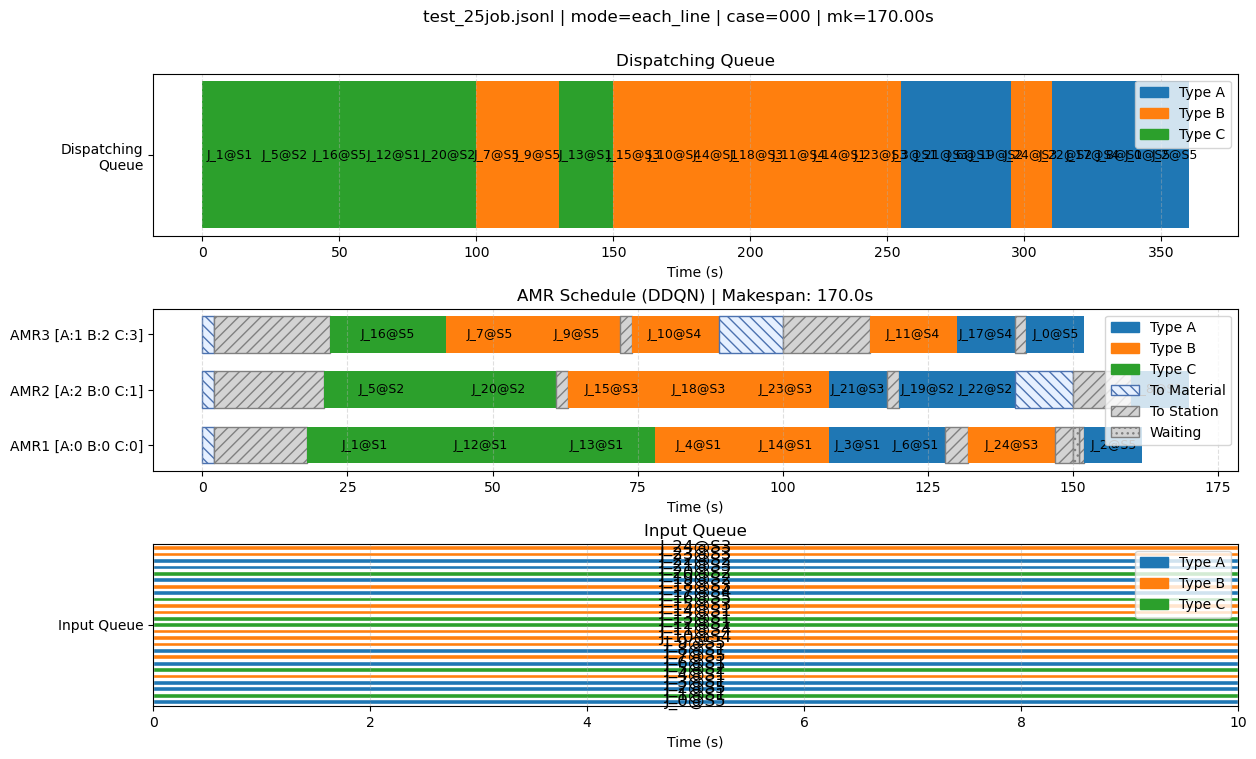

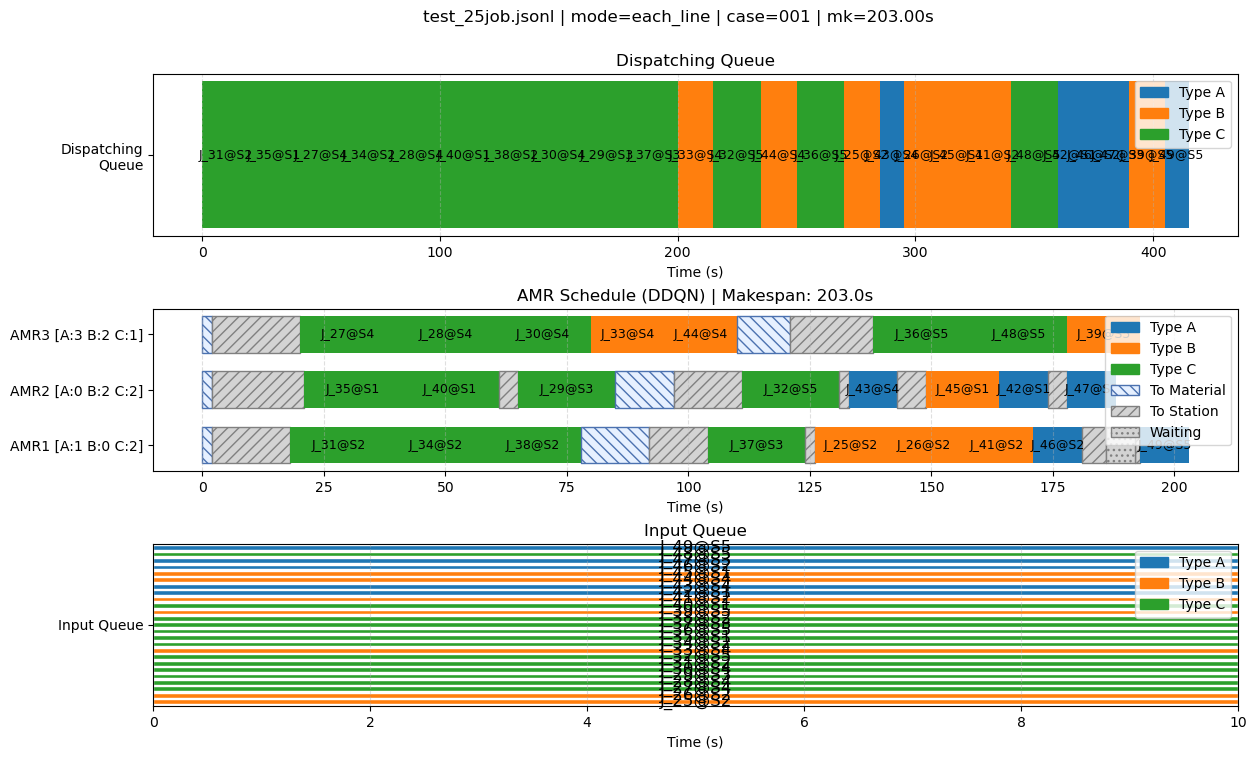

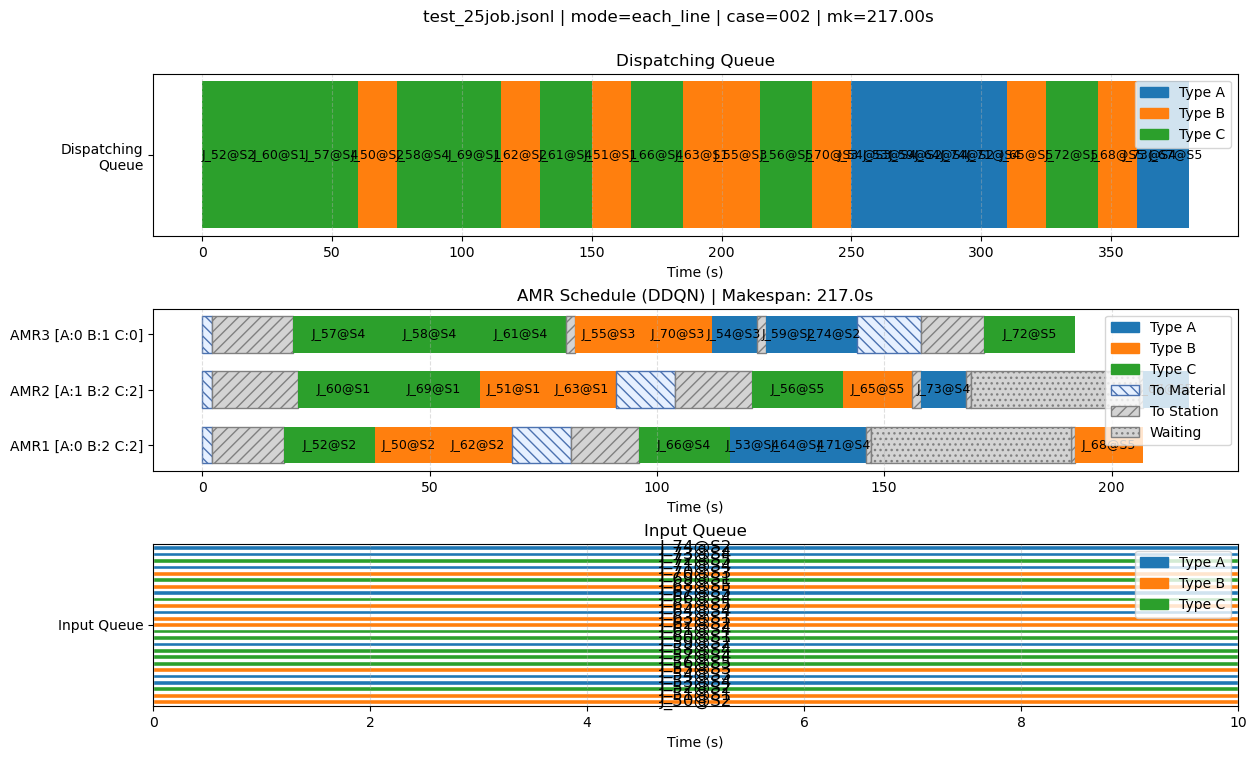

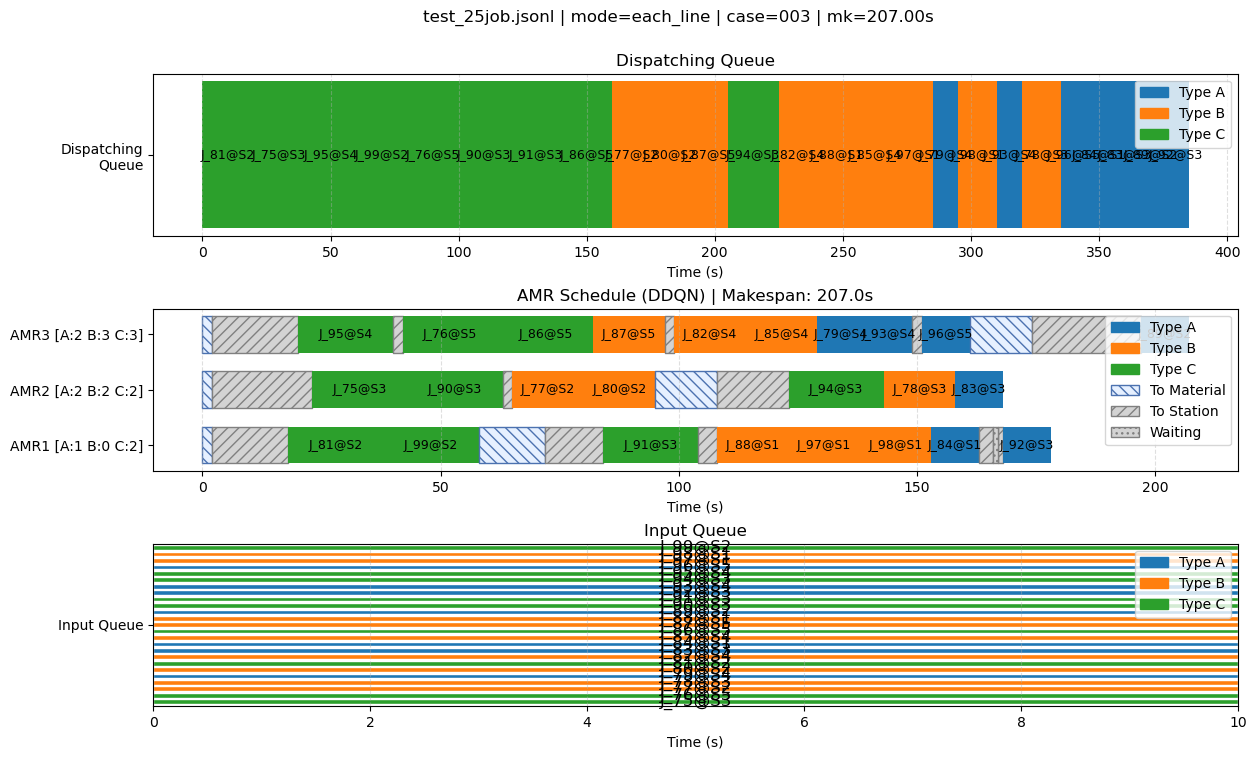

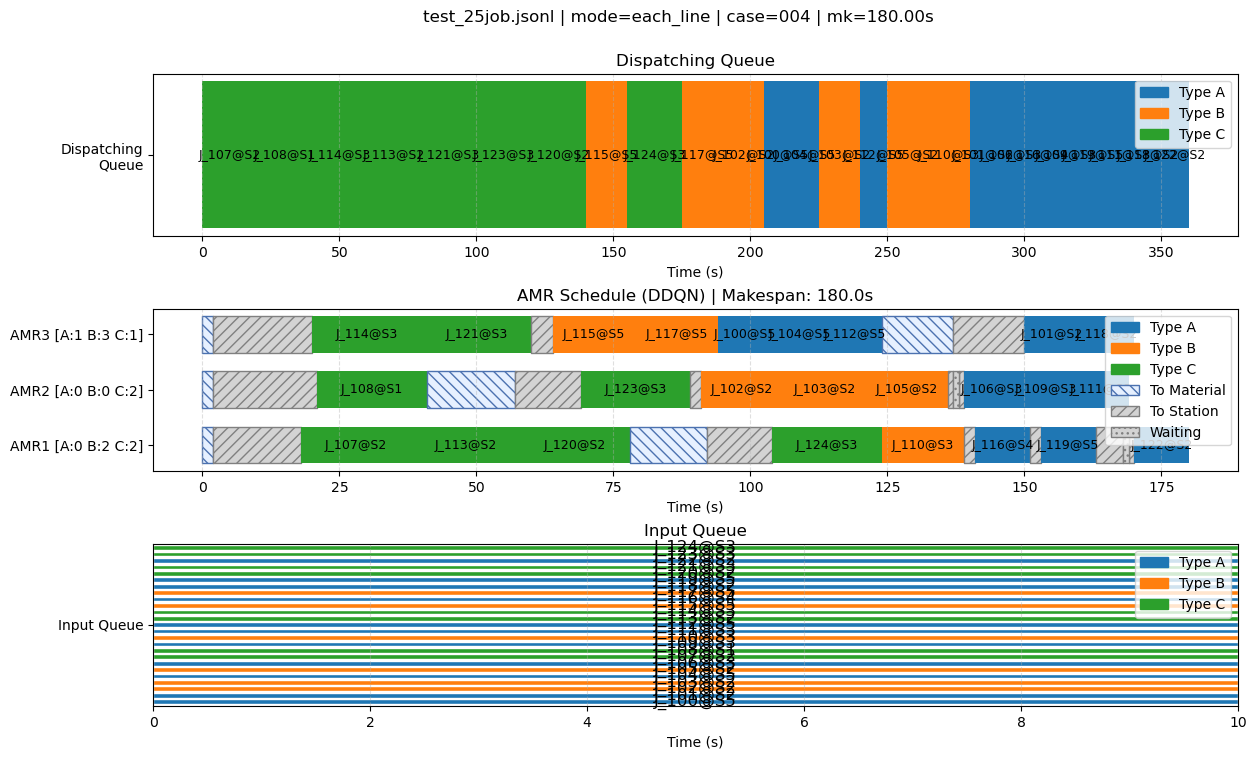

[test_25job.jsonl] CASE 000 makespan=170.000 solve_ms=60.955 solve_s=0.060955
[test_25job.jsonl] CASE 001 makespan=203.000 solve_ms=84.190 solve_s=0.084190
[test_25job.jsonl] CASE 002 makespan=217.000 solve_ms=73.778 solve_s=0.073778
[test_25job.jsonl] CASE 003 makespan=207.000 solve_ms=55.501 solve_s=0.055501
[test_25job.jsonl] CASE 004 makespan=180.000 solve_ms=64.712 solve_s=0.064712
[test_25job.jsonl] SOLVE_TIME avg=67.827ms total=339.136ms cases=5


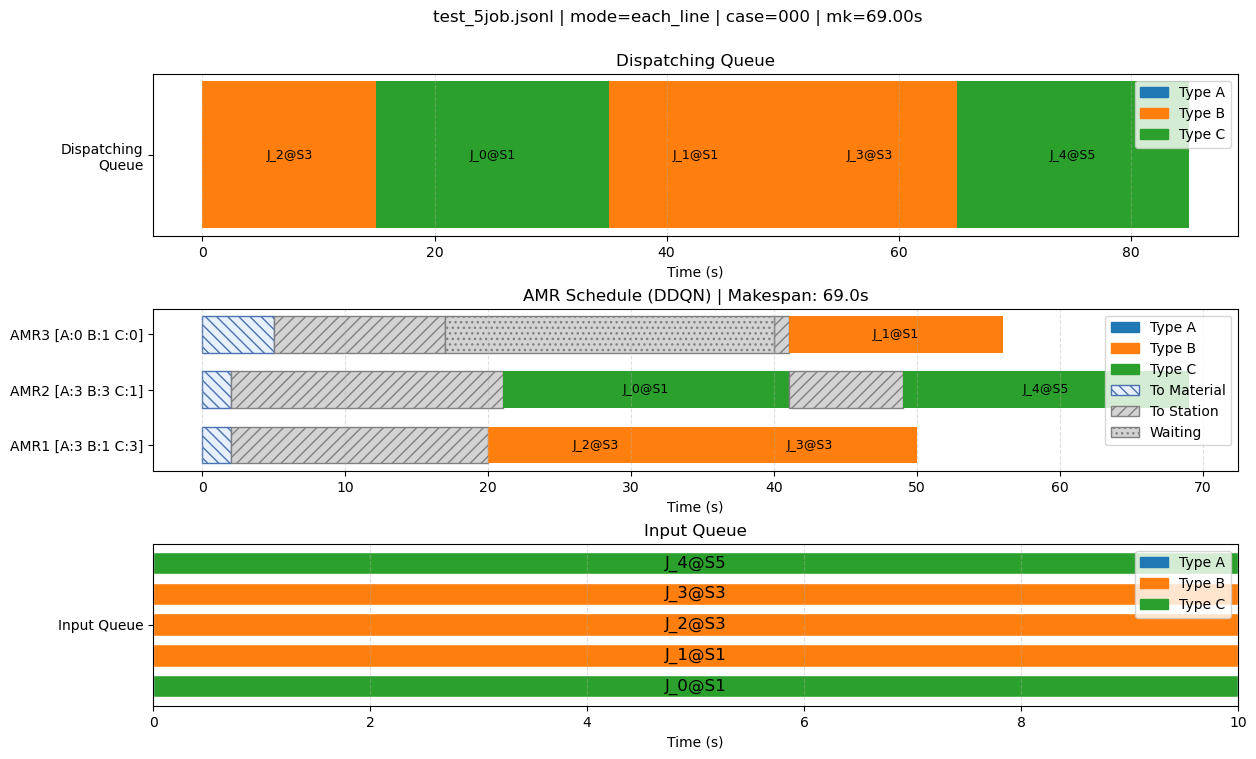

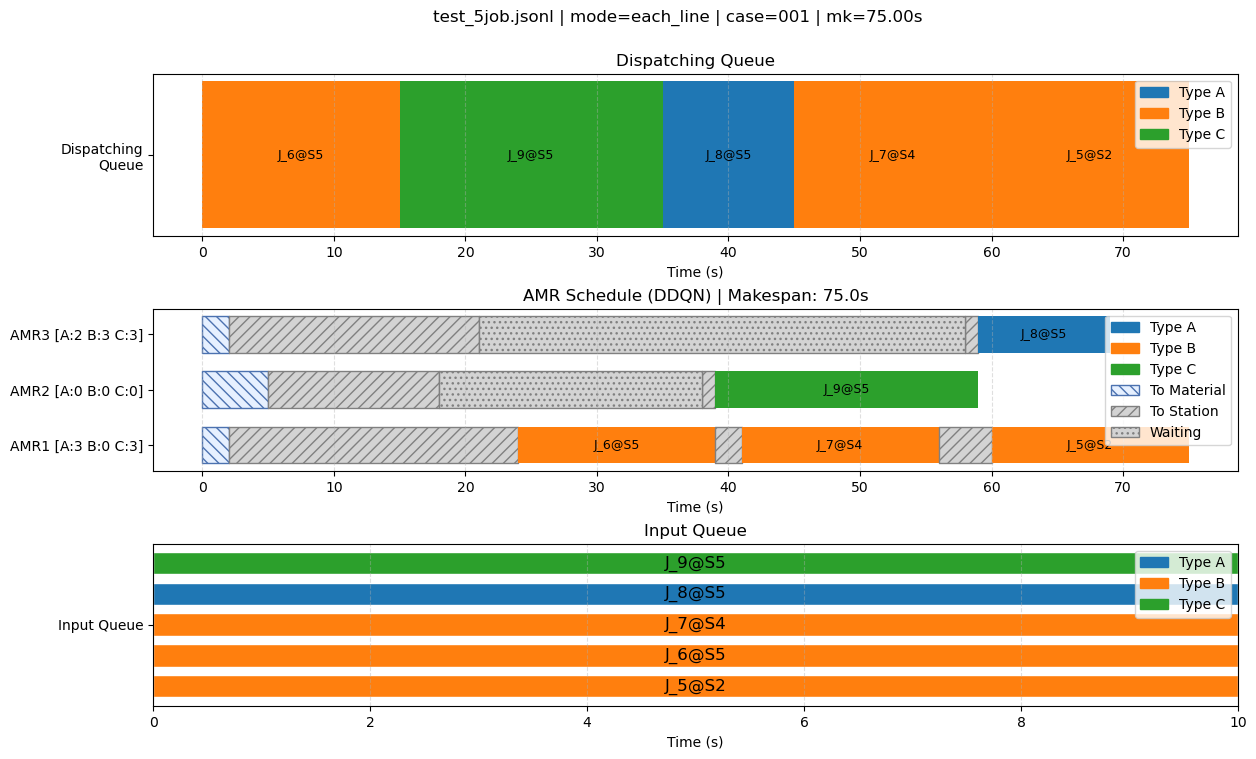

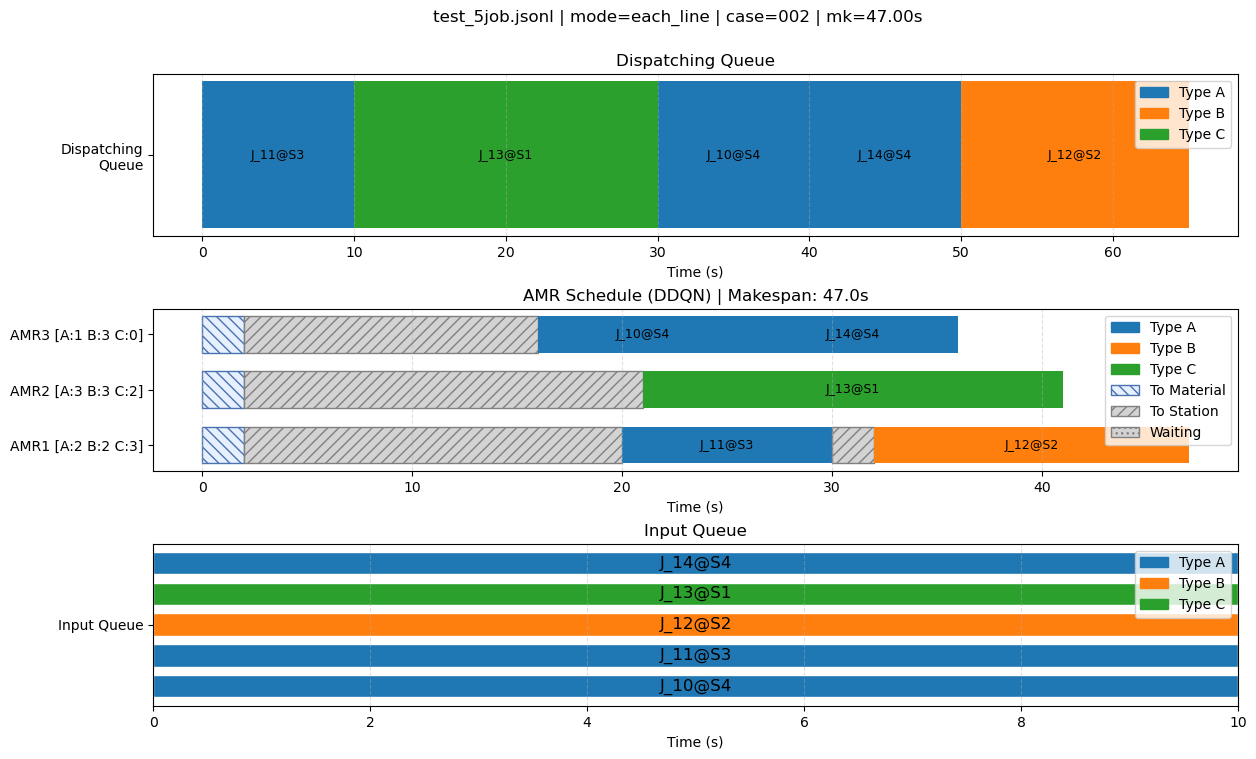

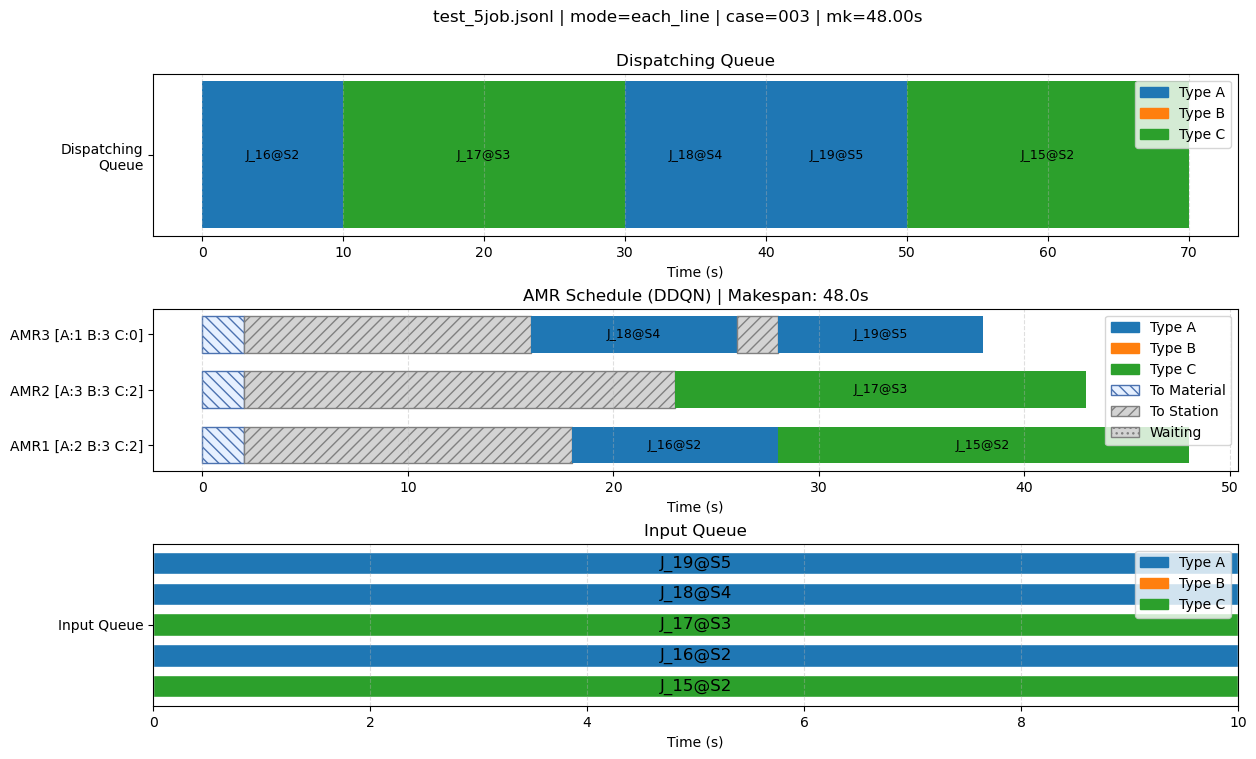

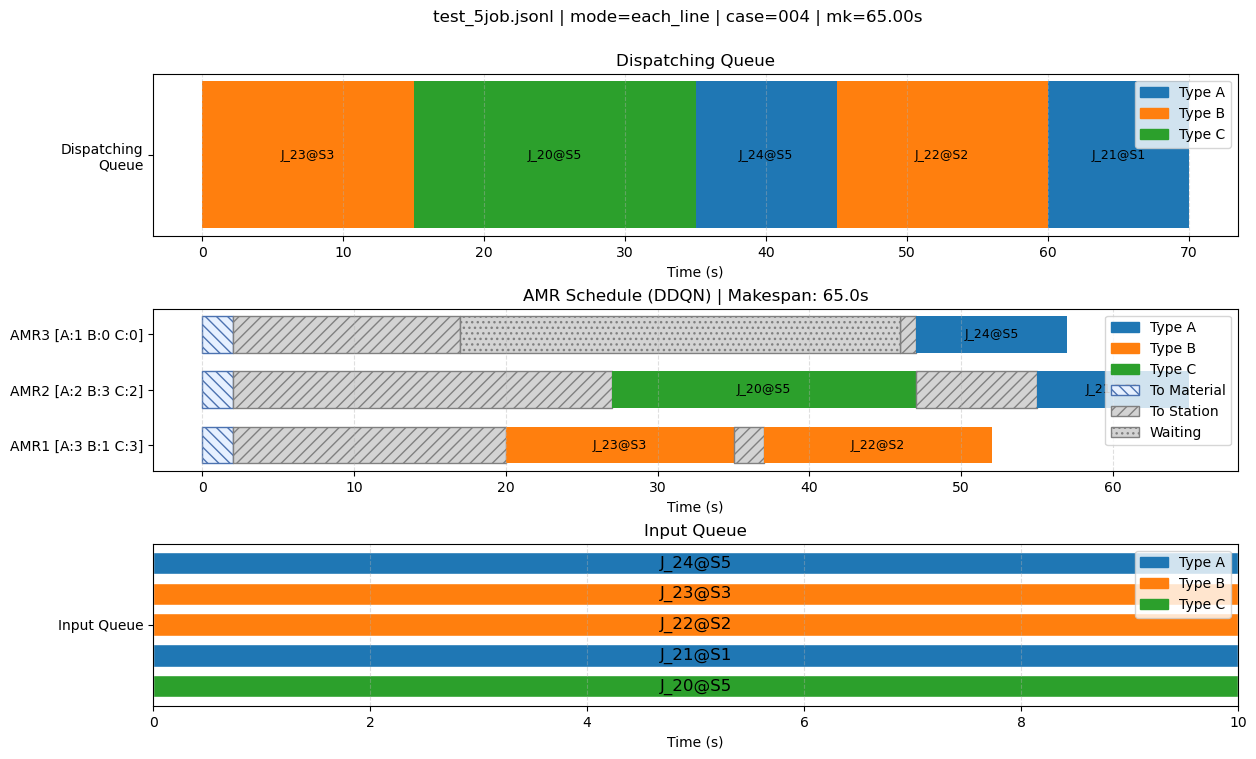

[test_5job.jsonl] CASE 000 makespan=69.000 solve_ms=14.406 solve_s=0.014406
[test_5job.jsonl] CASE 001 makespan=75.000 solve_ms=11.785 solve_s=0.011785
[test_5job.jsonl] CASE 002 makespan=47.000 solve_ms=10.808 solve_s=0.010808
[test_5job.jsonl] CASE 003 makespan=48.000 solve_ms=17.040 solve_s=0.017040
[test_5job.jsonl] CASE 004 makespan=65.000 solve_ms=19.385 solve_s=0.019385
[test_5job.jsonl] SOLVE_TIME avg=14.685ms total=73.423ms cases=5

====== PER-FILE SUMMARY ======
test_10job.jsonl: cases=5 mk_avg=100.000 mk_min=89.000 mk_max=131.000 solve_ms_avg=27.420 solve_ms_total=137.098
test_15job.jsonl: cases=5 mk_avg=135.000 mk_min=114.000 mk_max=173.000 solve_ms_avg=42.743 solve_ms_total=213.715
test_20job.jsonl: cases=5 mk_avg=153.800 mk_min=140.000 mk_max=176.000 solve_ms_avg=53.058 solve_ms_total=265.290
test_25job.jsonl: cases=5 mk_avg=195.400 mk_min=170.000 mk_max=217.000 solve_ms_avg=67.827 solve_ms_total=339.136
test_5job.jsonl: cases=5 mk_avg=60.800 mk_min=47.000 mk_max=75.000 s

In [4]:
# Example A: test a single jsonl as one multi-dispatch scenario
# TEST_CFG = {
#     "target_path": "test_case/case_04_train_stream_000.jsonl",
#     "model_path": "ddqn_policy_rainbow.pt",
#     "case_mode": "full_stream",
# }

# Example B: test a single jsonl line-by-line (each line as one single-dispatch case)
# TEST_CFG = {
#     "target_path": "test_case/case_04_train_stream_000.jsonl",
#     "model_path": "ddqn_policy_rainbow.pt",
#     "case_mode": "each_line",
# }

# Example C: test all jsonl in test_case folder
TEST_CFG = {
    "target_path": "test_case",
    "model_path": "ddqn_policy_rainbow.pt",
    "case_mode": "each_line",      # "full_stream" | "each_line"
    "max_files": None,                 # e.g. 3
    "max_cases_per_file": None,        # only used when each_line
    "plot": True,
    "save_plots": True,
    "plot_dir": "test_plots",
    "show_route_map": False,
    "show_plotly": False,            # True => generate HTML via viz_plotly.py
    "plotly_html_dir": "test_plots_html",
    "plotly_window": 80.0,
    "plotly_step": 5.0,
    "save_route_jsonl": True,       # True => export per-second AMR route log jsonl
    "route_jsonl_dir": "test_route_logs",
    "route_time_step": 1.0,
    "save_stats_txt": True,         # True => export case + summary stats to txt
    "stats_txt_path": "test_output/test_stats.txt",
    "stats_txt_append": True,
    "allow_proactive_replenish": True,
    "proactive_replenish_bias_weight": 1.5,
    "proactive_full_load_bias_weight": 0.8,
    "proactive_waiting_replenish_bias_weight": 1.2,
    "enable_collision_avoidance": False,
    "print_predict_time": True,        # True => print elapsed time for every prediction step
}

results = run_tests(**TEST_CFG)
print(f"result_rows = {len(results)}")
